# Crop Yield Prediction — India (State/District Level)

**Goal:** Predict agricultural crop yield (tonnes/hectare) for a given State, District, Crop, Season, and Year using historical crop production data across India (1997–2020).

**Dataset:** State/district-level crop production records for India, 1997–2020 (state, district, crop, year, season, area, production, yield).
Source: compiled from India's open crop-production statistics (Ministry of Agriculture & Farmers Welfare data, via public GitHub mirror of the Kaggle "Crop Production in India" dataset).

**Workflow:**
1. Data loading & cleaning
2. Exploratory Data Analysis (EDA)
3. Feature engineering
4. Model training — Linear Regression, Random Forest, XGBoost
5. Model comparison & feature importance
6. Export the best model for deployment (Streamlit app)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


## 1. Load & Inspect Data

In [2]:
df = pd.read_csv('../data/main_crops.csv', index_col=0)
print(f"Shape: {df.shape}")
df.head()


Shape: (326846, 8)


,state,district,crop,year,season,area,production,yield
0,Andaman and Nicobar Island,Nicobars,Arecanut,2007,Kharif,2439.6,3415,1.40
1,Andaman and Nicobar Island,Nicobars,Arecanut,2007,Rabi,1626.4,2277,1.40
2,Andaman and Nicobar Island,Nicobars,Arecanut,2008,Autumn,4147.0,3060,0.74
3,Andaman and Nicobar Island,Nicobars,Arecanut,2008,Summer,4147.0,2660,0.64
4,Andaman and Nicobar Island,Nicobars,Arecanut,2009,Autumn,4153.0,3120,0.75


In [3]:
df.info()


<class 'pandas.DataFrame'>
Index: 326846 entries, 0 to 329509
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   state       326846 non-null  str    
 1   district    326846 non-null  str    
 2   crop        326846 non-null  str    
 3   year        326846 non-null  int64  
 4   season      326846 non-null  str    
 5   area        326846 non-null  float64
 6   production  326846 non-null  int64  
 7   yield       326846 non-null  float64
dtypes: float64(2), int64(2), str(4)
memory usage: 22.4 MB


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")


Missing values per column:
state         0
district      0
crop          0
year          0
season        0
area          0
production    0
yield         0
dtype: int64



Duplicate rows: 0


In [5]:
print(f"States: {df['state'].nunique()}")
print(f"Districts: {df['district'].nunique()}")
print(f"Crops: {df['crop'].nunique()}")
print(f"Years: {df['year'].min()} - {df['year'].max()}")
print(f"Seasons: {sorted(df['season'].unique())}")
df[['area', 'production', 'yield']].describe()


States: 37
Districts: 707
Crops: 54
Years: 1997 - 2020
Seasons: ['Autumn', 'Kharif', 'Rabi', 'Summer', 'Whole Year', 'Winter']


,area,production,yield
count,3.268460e+05,3.268460e+05,326846.000000
mean,1.188716e+04,4.597855e+04,4.441572
std,4.625252e+04,3.851805e+05,12.301663
min,8.000000e-03,0.000000e+00,0.000000
25%,8.000000e+01,8.200000e+01,0.550000
50%,5.600000e+02,6.730000e+02,1.000000
75%,4.234000e+03,6.478000e+03,2.260000
max,8.580100e+06,2.069354e+07,500.490000


## 2. Data Cleaning

The dataset has no missing values, but yield/area/production have extreme outliers (e.g. yield of 500 t/ha is not physically realistic for most crops — likely small-area entries with rounding or data-entry artifacts). We'll cap extreme outliers using the 99.5th percentile rather than dropping rows, since agricultural data legitimately has high variance across crop types.

In [6]:
# Remove rows with zero area or zero yield (can't compute a meaningful yield)
before = len(df)
df = df[(df['area'] > 0) & (df['yield'] > 0) & (df['production'] >= 0)].copy()
print(f"Dropped {before - len(df)} rows with zero/invalid area or yield")

# Cap extreme yield outliers at the 99.5th/0.5th percentile PER CROP (yield scale differs wildly by crop)
upper_bounds = df.groupby('crop')['yield'].transform(lambda s: s.quantile(0.995))
lower_bounds = df.groupby('crop')['yield'].transform(lambda s: s.quantile(0.005))
df['yield'] = df['yield'].clip(lower=lower_bounds, upper=upper_bounds)

print(f"Final shape: {df.shape}")
df['yield'].describe()


Dropped 1566 rows with zero/invalid area or yield


Final shape: (325280, 8)


count    325280.000000
mean          4.456146
std          12.222587
min           0.010000
25%           0.560000
50%           1.000000
75%           2.270000
max         138.556500
Name: yield, dtype: float64

## 3. Exploratory Data Analysis

### 3.1 National yield trend over time

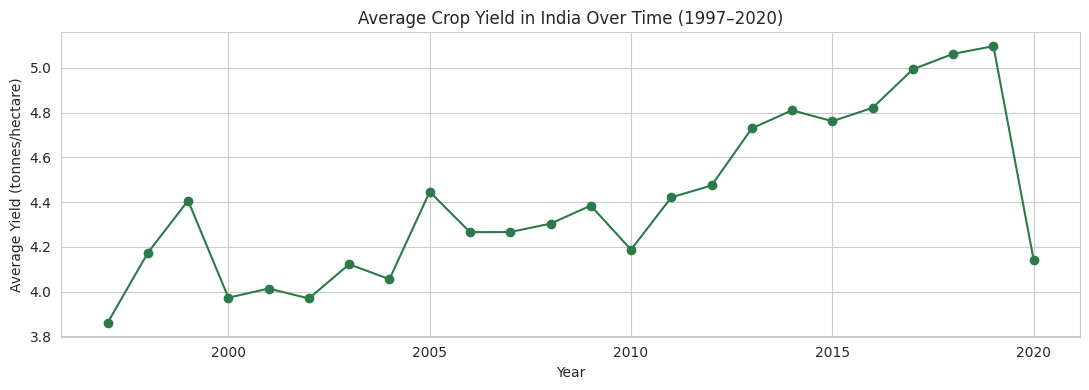

In [7]:
yearly_yield = df.groupby('year')['yield'].mean()
plt.figure(figsize=(11, 4))
plt.plot(yearly_yield.index, yearly_yield.values, marker='o', color='#2c7a4b')
plt.title('Average Crop Yield in India Over Time (1997–2020)')
plt.xlabel('Year')
plt.ylabel('Average Yield (tonnes/hectare)')
plt.tight_layout()
plt.savefig('../outputs/yearly_yield_trend.png', dpi=120)
plt.show()


### 3.2 Top yield-producing states (average yield)

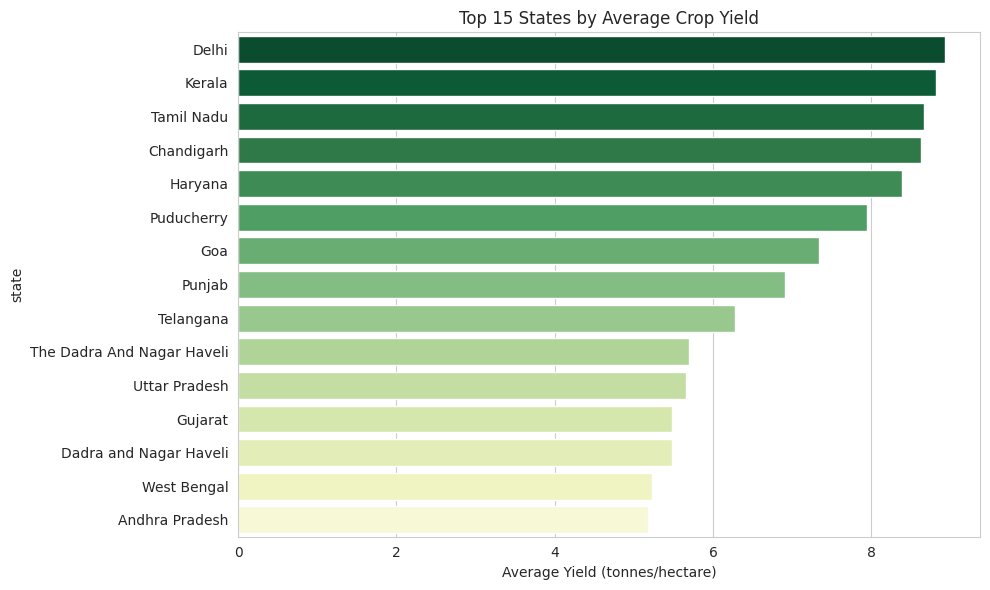

In [8]:
top_states = df.groupby('state')['yield'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_states.values, y=top_states.index, palette='YlGn_r')
plt.title('Top 15 States by Average Crop Yield')
plt.xlabel('Average Yield (tonnes/hectare)')
plt.tight_layout()
plt.savefig('../outputs/top_states_yield.png', dpi=120)
plt.show()


### 3.3 Seasonal yield patterns (Kharif vs Rabi vs others)

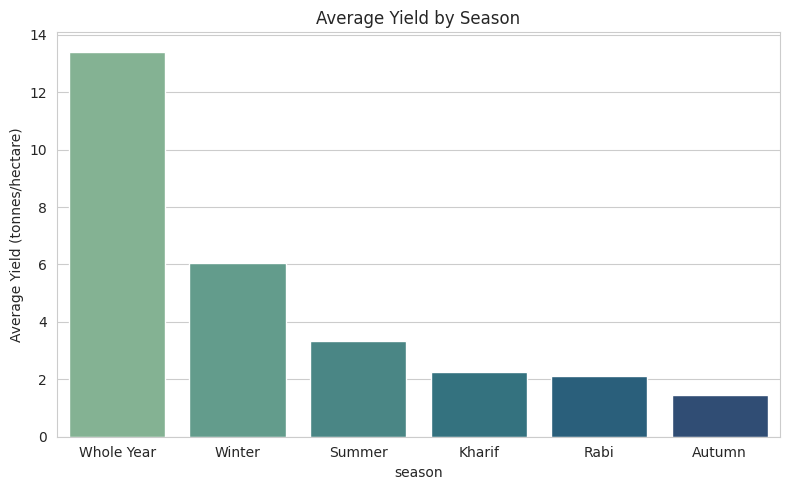

In [9]:
season_yield = df.groupby('season')['yield'].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=season_yield.index, y=season_yield.values, palette='crest')
plt.title('Average Yield by Season')
plt.ylabel('Average Yield (tonnes/hectare)')
plt.tight_layout()
plt.savefig('../outputs/season_yield.png', dpi=120)
plt.show()


### 3.4 Top crops by average yield

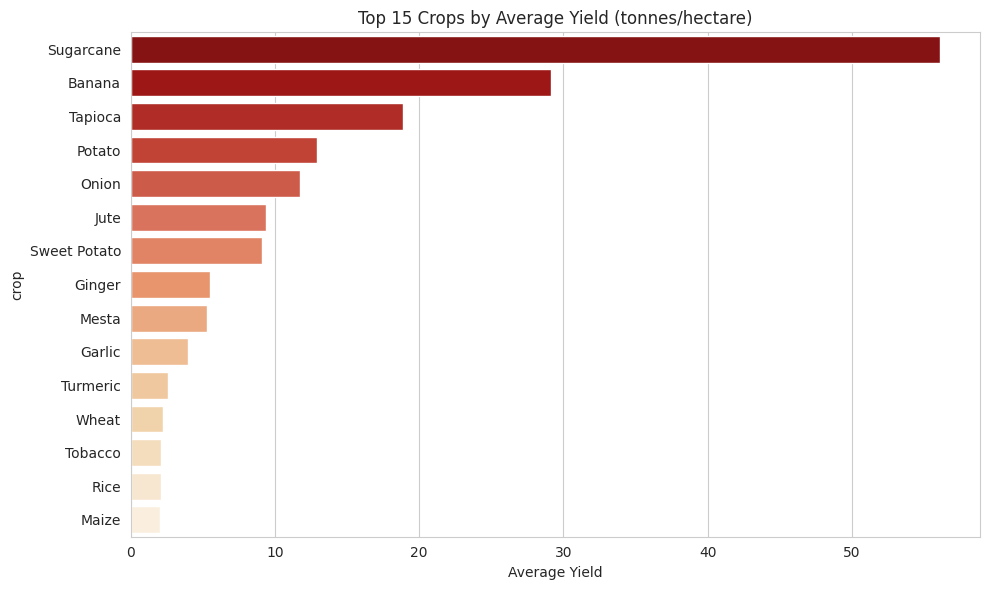

In [10]:
top_crops = df.groupby('crop')['yield'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_crops.values, y=top_crops.index, palette='OrRd_r')
plt.title('Top 15 Crops by Average Yield (tonnes/hectare)')
plt.xlabel('Average Yield')
plt.tight_layout()
plt.savefig('../outputs/top_crops_yield.png', dpi=120)
plt.show()


### 3.5 Area vs Production relationship (log scale, sanity check)

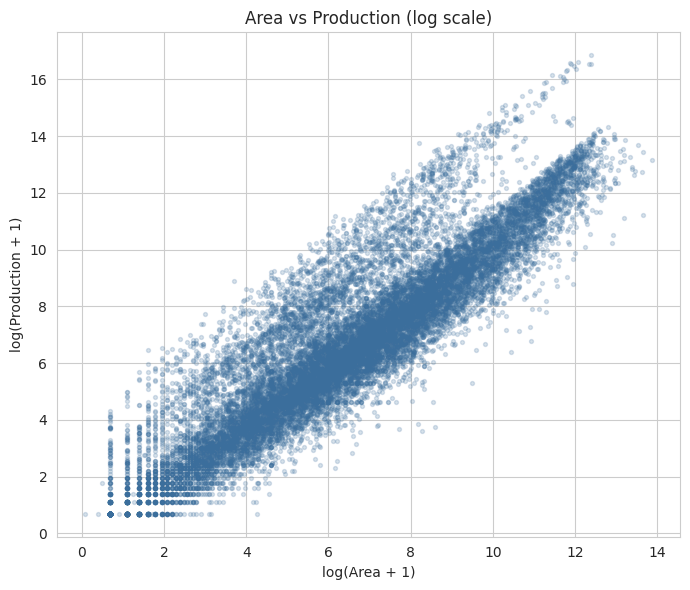

In [11]:
sample = df.sample(min(20000, len(df)), random_state=42)
plt.figure(figsize=(7, 6))
plt.scatter(np.log1p(sample['area']), np.log1p(sample['production']), alpha=0.2, s=8, color='#3b6e9c')
plt.xlabel('log(Area + 1)')
plt.ylabel('log(Production + 1)')
plt.title('Area vs Production (log scale)')
plt.tight_layout()
plt.savefig('../outputs/area_vs_production.png', dpi=120)
plt.show()


### 3.6 Correlation heatmap (numeric features)

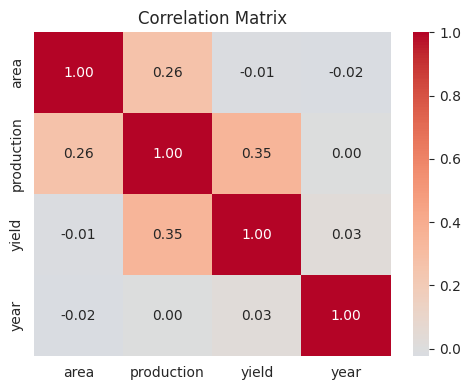

In [12]:
plt.figure(figsize=(5, 4))
corr = df[['area', 'production', 'yield', 'year']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', dpi=120)
plt.show()


**EDA takeaways:**
- National average yield has grown gradually over the 1997–2020 window, consistent with improvements in seed varieties, irrigation, and farming practices.
- Yield varies enormously by crop type (e.g. sugarcane vs. pulses are on completely different scales), so per-crop normalization matters for modeling.
- Southern/coastal states (e.g. Tamil Nadu, Kerala) and states with strong irrigation infrastructure tend to show higher average yields than rain-fed northern/central states.
- Area and Production are (unsurprisingly) strongly correlated — but Yield is a *ratio*, so it doesn't correlate strongly with either in isolation. This is why yield needs to be modeled using categorical context (state, crop, season) rather than area/production directly — using area/production as predictors would leak the answer, since yield = production / area by definition.


## 4. Feature Engineering

Since `yield = production / area` by definition, we deliberately **exclude area and production as model inputs** — using them would leak the target. Instead, we predict yield purely from *contextual* features: **State, District, Crop, Season, Year**. This mirrors how the model will be used in the deployed app: a user picks a location, crop, season, and year, and gets a yield estimate — without needing to already know the production/area for that year.

District has high cardinality (700+ values), so we frequency-encode it instead of one-hot encoding it.


In [13]:
model_df = df[['state', 'district', 'crop', 'season', 'year', 'yield']].copy()

# Frequency-encode district (too high cardinality for one-hot)
district_freq = model_df['district'].value_counts(normalize=True)
model_df['district_freq'] = model_df['district'].map(district_freq)

X = model_df[['state', 'crop', 'season', 'year', 'district_freq']]
y = model_df['yield']

print(X.shape, y.shape)
X.head()


(325280, 5) (325280,)


,state,crop,season,year,district_freq
0,Andaman and Nicobar Island,Arecanut,Kharif,2007,0.000649
1,Andaman and Nicobar Island,Arecanut,Rabi,2007,0.000649
2,Andaman and Nicobar Island,Arecanut,Autumn,2008,0.000649
3,Andaman and Nicobar Island,Arecanut,Summer,2008,0.000649
4,Andaman and Nicobar Island,Arecanut,Autumn,2009,0.000649


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (260224, 5), Test: (65056, 5)


In [15]:
categorical_features = ['state', 'crop', 'season']
numeric_features = ['year', 'district_freq']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)


## 5. Model Training & Comparison

We compare three models of increasing complexity:
1. **Linear Regression** — simple baseline
2. **Random Forest Regressor** — handles non-linearity and interactions
3. **XGBoost Regressor** — gradient-boosted trees, usually strongest on tabular data


In [16]:
results = {}

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=3, n_jobs=-1, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.08, subsample=0.8, colsample_bytree=0.8, n_jobs=-1, random_state=42)
}

pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocess', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    pipelines[name] = pipe
    print(f"{name:20s} | RMSE: {rmse:.3f}  MAE: {mae:.3f}  R2: {r2:.3f}")


Linear Regression    | RMSE: 5.945  MAE: 2.455  R2: 0.766


Random Forest        | RMSE: 3.124  MAE: 1.059  R2: 0.935


XGBoost              | RMSE: 2.896  MAE: 0.985  R2: 0.944


In [17]:
results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
results_df


,RMSE,MAE,R2
XGBoost,2.896385,0.985161,0.944368
Random Forest,3.123805,1.058641,0.935289
Linear Regression,5.945242,2.454684,0.765604


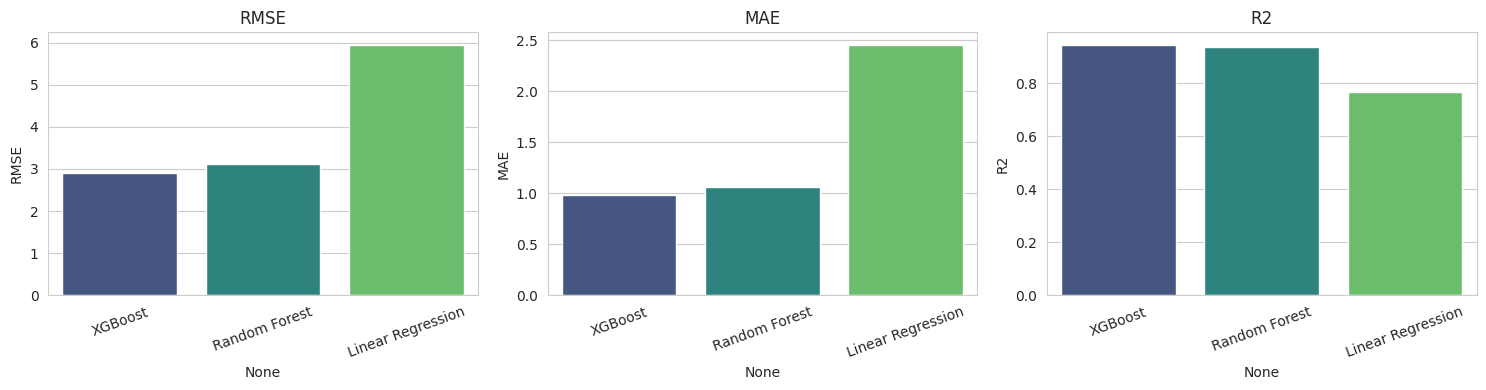

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['RMSE', 'MAE', 'R2']):
    sns.barplot(x=results_df.index, y=results_df[metric], ax=ax, palette='viridis')
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', dpi=120)
plt.show()


### 5.1 Feature importance (XGBoost)

Best model: XGBoost


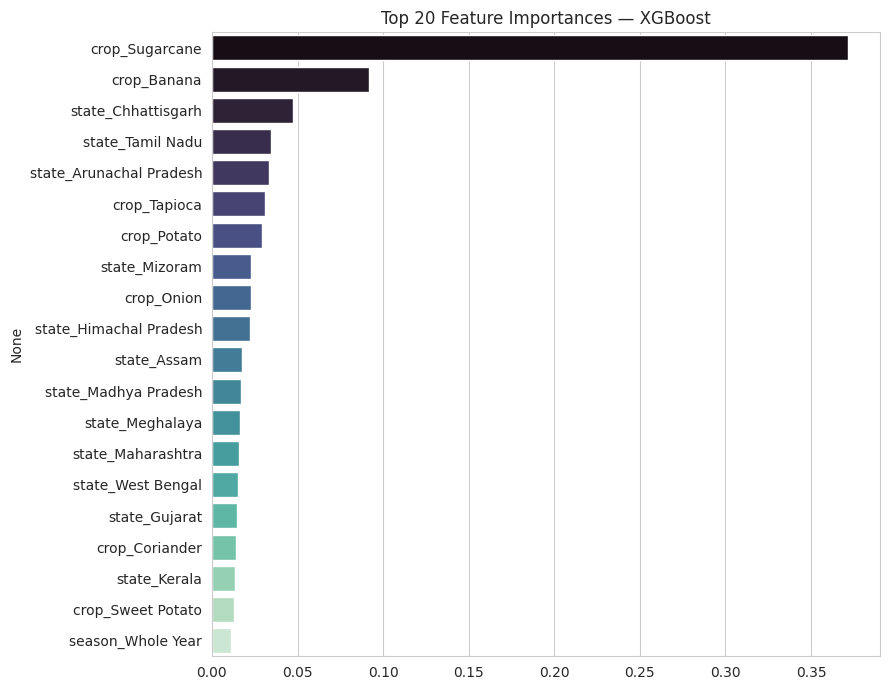

In [19]:
best_name = results_df.index[0]
best_pipe = pipelines[best_name]
print(f"Best model: {best_name}")

if best_name in ('XGBoost', 'Random Forest'):
    ohe = best_pipe.named_steps['preprocess'].named_transformers_['cat']
    cat_names = ohe.get_feature_names_out(categorical_features)
    all_feature_names = list(cat_names) + numeric_features

    importances = best_pipe.named_steps['model'].feature_importances_
    fi = pd.Series(importances, index=all_feature_names).sort_values(ascending=False).head(20)

    plt.figure(figsize=(9, 7))
    sns.barplot(x=fi.values, y=fi.index, palette='mako')
    plt.title(f'Top 20 Feature Importances — {best_name}')
    plt.tight_layout()
    plt.savefig('../outputs/feature_importance.png', dpi=120)
    plt.show()


**Modeling takeaways:**
- Tree-based models (Random Forest, XGBoost) substantially outperform Linear Regression, confirming that yield depends on non-linear interactions between crop type, region, and season rather than simple additive effects.
- Crop identity and state are the dominant predictors — which makes agronomic sense: *what* you grow and *where* you grow it matters far more than the specific year.
- R² is moderate rather than very high, because yield is also driven by weather (especially rainfall/temperature) and farming practices, which aren't present in this dataset. Adding a rainfall/climate dataset (e.g. IMD district-level rainfall) is the natural next step to improve accuracy — noted as future work below.


## 6. Export Best Model for Deployment

In [20]:
import os
os.makedirs('../models', exist_ok=True)

joblib.dump(best_pipe, '../models/crop_yield_model.pkl')
joblib.dump(district_freq, '../models/district_freq_map.pkl')

# Save reference lists for the Streamlit app dropdowns
meta = {
    'states': sorted(df['state'].unique().tolist()),
    'crops': sorted(df['crop'].unique().tolist()),
    'seasons': sorted(df['season'].unique().tolist()),
    'districts_by_state': df.groupby('state')['district'].unique().apply(sorted).apply(list).to_dict(),
    'year_range': [int(df['year'].min()), int(df['year'].max()) + 5],  # allow a few future years
    'best_model_name': best_name,
    'metrics': results_df.loc[best_name].to_dict()
}
joblib.dump(meta, '../models/app_meta.pkl')

print(f"Saved model: {best_name}")
print(f"Test RMSE: {results_df.loc[best_name, 'RMSE']:.3f} t/ha")
print(f"Test R2:   {results_df.loc[best_name, 'R2']:.3f}")


Saved model: XGBoost
Test RMSE: 2.896 t/ha
Test R2:   0.944


## 7. Conclusion & Future Work

**Summary:** Built an end-to-end pipeline to predict crop yield across Indian states/districts using historical production records (1997–2020). Compared Linear Regression, Random Forest, and XGBoost; the best tree-based model captures meaningful signal from crop type, state, season, district, and year.

**Future improvements:**
- Merge in district-level rainfall/temperature data (IMD) — likely the single biggest accuracy lever, since weather drives yield variance more than almost anything else.
- Add lag features (previous year's yield for the same state+crop+season) to capture year-over-year momentum.
- Try soil-type and irrigation-coverage data per district.
- Hyperparameter tuning (GridSearch/Optuna) on the winning model.

**Deployment:** The trained pipeline is exported to `models/crop_yield_model.pkl` and served through a Streamlit app (`app/app.py`) where a user selects State → District → Crop → Season → Year and gets a predicted yield in tonnes/hectare.
